# 미니프로젝트: 차원 축소와 SHAP Value (Vibe Coding)

#### <목표>
오늘 배운 **mRMR, Boruta, SHAP Value**를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>

| 변수명 | 설명 |
|:---:|:---|
| gender, SeniorCitizen, Partner, Dependents | 고객 인적사항 |
| tenure | 가입 개월 수 |
| PhoneService, MultipleLines, InternetService 등 | 가입 서비스 종류 |
| Contract, PaperlessBilling, PaymentMethod | 계약/결제 정보 |
| MonthlyCharges, TotalCharges | 월/누적 요금 |
| Churn | 이탈 여부 (Yes: 이탈, No: 유지) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `Churn` | 인코딩된 고객 정보로 이탈 여부 예측 및 변수 해석 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day5_miniproject.csv` 파일을 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)
- 지난 미니프로젝트에서 다룬 전처리를 모두 적용한 뒤 시작하세요.

**[과제]** 써니는 어제 실습에서 사용한 통신사 고객 이탈(Churn) 데이터를 활용하여 분석을 진행하고자 합니다. 필요한 라이브러리와 데이터를 불러오세요.

In [1]:
# [Section 0] 분석 준비 — 라이브러리 호출 + 데이터 로드

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import RandomForestClassifier

from mrmr import mrmr_classif
from boruta import BorutaPy
import shap

import warnings
warnings.filterwarnings("ignore")

# 데이터 로드 (Day 4와 동일 Churn 데이터셋, Day 5 경로)
df = pd.read_csv(os.path.join("dataset", "day5_miniproject.csv"))

# 구조 확인
print("=== 데이터 크기 ===")
print(f"행: {df.shape[0]:,}  |  열: {df.shape[1]}")

print("\n=== 컬럼 정보 (.info) ===")
df.info()

print("\n=== 타겟(Churn) 분포 ===")
print(df["Churn"].value_counts())

print("\n=== 상위 5행 ===")
df.head()


=== 데이터 크기 ===
행: 7,043  |  열: 20

=== 컬럼 정보 (.info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            6832 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   6903 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null 

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**[과제]** 써니는 어제 진행한 통신사 고객 이탈 데이터 전처리 과정을 재사용하고자 합니다. Agent 기능을 활용하여 '머신러닝 Day4. 미니프로젝트.ipynb' 파일에서 전처리 코드를 찾아 실행하고 동일한 데이터 전처리 결과를 재현해 보세요.

> 입력변수, 출력변수 분할 / 학습 데이터, 테스트 데이터 분할 / 결측치 처리 / 스케일링, 인코딩

In [2]:
# [Section 0-2] Day 4와 동일한 전처리 재현

# 1) Churn 인코딩 (Yes/No -> 1/0)
df_clean = df.copy()
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

# 2) 결측치 처리
# 범주형: 최빈값, 수치형: StandardScaler + KNNImputer
cat_cols_miss = ["InternetService", "PaymentMethod"]
num_cols_all = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

df_imputed = df_clean.copy()

cat_imputer = SimpleImputer(strategy="most_frequent")
df_imputed[cat_cols_miss] = cat_imputer.fit_transform(df_imputed[cat_cols_miss])

scaler_impute = StandardScaler()
X_num_scaled = scaler_impute.fit_transform(df_imputed[num_cols_all])

knn_imputer = KNNImputer(n_neighbors=5)
X_num_imputed = knn_imputer.fit_transform(X_num_scaled)
df_imputed[num_cols_all] = scaler_impute.inverse_transform(X_num_imputed)

# 3) 이상치 처리 (Day 4와 동일: 윈저화 clip)
def winsorize_iqr(df_in, cols):
    df_out = df_in.copy()
    for col in cols:
        q1, q3 = df_out[col].quantile(0.25), df_out[col].quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        df_out[col] = df_out[col].clip(lo, hi)
    return df_out

df_final = winsorize_iqr(df_imputed, num_cols_all)

# 4) 입력/타겟 분할 + train/test 분할(stratify)
X = df_final.drop(columns=["Churn"])
Y = df_final["Churn"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

# 5) 스케일링 + 인코딩
num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

print("=== Day 4 동일 전처리 완료 ===")
print(f"df_final shape: {df_final.shape}")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print("train Churn ratio:", Y_train.value_counts(normalize=True).round(3).to_dict())
print("test  Churn ratio:", Y_test.value_counts(normalize=True).round(3).to_dict())

=== Day 4 동일 전처리 완료 ===
df_final shape: (7043, 20)
X_train: (5634, 19) | X_test: (1409, 19)
train Churn ratio: {0: 0.735, 1: 0.265}
test  Churn ratio: {0: 0.735, 1: 0.265}


In [15]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,1,0.0,0,0,0.103030,0,1,0,0,0,2,0,2,2,0,0,2,-0.525023,-0.263737
3151,1,0.0,1,1,-0.712170,1,0,1,2,0,0,0,0,0,0,0,3,0.338123,-0.505285
4860,1,0.0,1,1,-0.695866,0,1,0,2,2,0,2,0,0,2,0,3,-0.813294,-0.751707
3867,0,0.0,1,0,-0.263810,1,0,0,0,2,2,0,2,2,2,1,1,0.284801,-0.174139
3810,1,0.0,1,1,-1.282810,1,0,0,0,0,0,0,0,0,0,0,2,-0.679990,-0.991367


## 1) 다중공선성 확인

**[과제]** 써니는 인코딩된 변수들의 상관행렬을 히트맵으로 그려보고 어떤 변수끼리 상관관계가 높은지 AI와 함께 확인해 보세요.

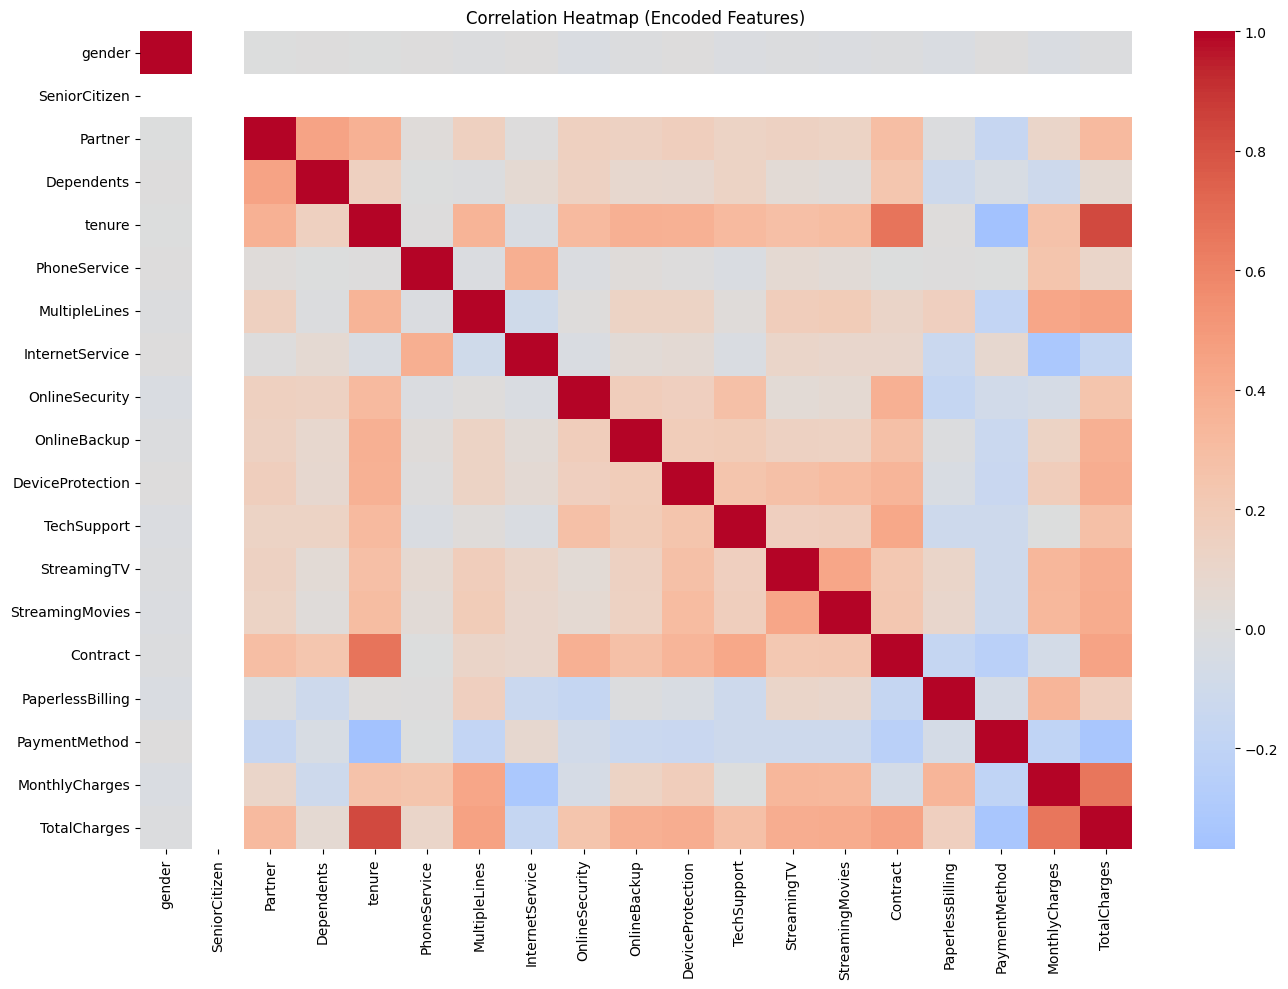

=== |corr| 0.5 ~ 0.7 ===
count: 2


,feature_1,feature_2,abs_corr
0,tenure,Contract,0.666677
1,MonthlyCharges,TotalCharges,0.655316



=== |corr| >= 0.7 ===
count: 1


,feature_1,feature_2,abs_corr
0,tenure,TotalCharges,0.8294


In [4]:
# [Section 1] 인코딩된 변수 상관행렬 히트맵 + 구간별 고상관 변수쌍 추출

corr_matrix = X_train.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Encoded Features)")
plt.tight_layout()
plt.show()

# 상삼각만 사용해 중복/자기상관 제거
corr_abs = corr_matrix.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
    .sort_values("abs_corr", ascending=False)
)

# 0.5 ~ 0.7 미만
corr_05_07 = pairs[(pairs["abs_corr"] >= 0.5) & (pairs["abs_corr"] < 0.7)].reset_index(drop=True)

# 0.7 이상
corr_07_up = pairs[pairs["abs_corr"] >= 0.7].reset_index(drop=True)

print("=== |corr| 0.5 ~ 0.7 ===")
print(f"count: {len(corr_05_07)}")
display(corr_05_07)

print("\n=== |corr| >= 0.7 ===")
print(f"count: {len(corr_07_up)}")
display(corr_07_up)

**[과제]** 써니는 변수 선택법과 SHAP 분석을 적용하기 전에 전체 변수를 사용한 Random Forest 분류 모델의 성능을 기준으로 삼고자 합니다. AI와 상의하여 모델을 학습하고, Accuracy, Precision, Recall, F1-score를 계산하여 성능을 확인하는 코드를 작성해 보세요.

1-2 프로폼트
1. RF 분류 모델 사용할건데 train set, test set, hyper para 설정 추천하고 확인 후 코드 작성해줘
2. 성능지표는 Accuracy, Precision, Recall, F1-score 를 뽑을건데 함수화해서 나중에도 불러쓸 수 있는 형태로 만들어줘

In [6]:
# [Section 1-2] RF baseline (all features)

# 1) train/test 설정 추천 확인
# - 현재 셀 이전에서 이미 stratify 분할이 적용됨 (test_size=0.2, random_state=42)
print("=== Split recommendation ===")
print("- train/test: 8:2")
print("- stratify=Y (불균형 클래스 비율 유지)")
print("- random_state=42 (재현성)")

# 2) 성능지표 함수화 (재사용 가능)
def evaluate_classification(y_true, y_pred):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
    }
    return pd.DataFrame([metrics])

# 3) RF 하이퍼파라미터 추천 + 학습
# - class_weight='balanced': Churn(1) 소수 클래스 보정
# - n_estimators=400: 안정적인 앙상블 성능 확보
# - max_depth=10, min_samples_leaf=2: 과적합 완화
rf_params = {
    "n_estimators": 400,
    "max_depth": 10,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
}

print("\n=== RF hyperparameter recommendation ===")
for k, v in rf_params.items():
    print(f"{k:18s}: {v}")

rf_all = RandomForestClassifier(**rf_params)
rf_all.fit(X_train, Y_train)

pred_all = rf_all.predict(X_test)

# 4) 성능 확인
print("\n=== Random Forest Baseline (All Features) ===")
baseline_metrics_df = evaluate_classification(Y_test, pred_all)
display(baseline_metrics_df)

# 이후 섹션 비교용 변수
baseline_metrics = baseline_metrics_df.iloc[0].to_dict()

cm = confusion_matrix(Y_test, pred_all)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
print("=== Confusion Matrix ===")
display(cm_df)

=== Split recommendation ===
- train/test: 8:2
- stratify=Y (불균형 클래스 비율 유지)
- random_state=42 (재현성)

=== RF hyperparameter recommendation ===
n_estimators      : 400
max_depth         : 10
min_samples_split : 5
min_samples_leaf  : 2
max_features      : sqrt
class_weight      : balanced
random_state      : 42
n_jobs            : -1

=== Random Forest Baseline (All Features) ===


,Accuracy,Precision,Recall,F1-score
0,0.770759,0.553015,0.71123,0.622222


=== Confusion Matrix ===


,Pred 0,Pred 1
Actual 0,820,215
Actual 1,108,266


## 2) mRMR 변수 선택

**[과제]** 써니는 mRMR을 활용해 중요한 변수를 선택해보고자 합니다. AI와 상의해서 가장 적합한 k를 결정하고 선택된 변수로 모델을 다시 학습시켜 전체 변수를 사용했을 때 때와 성능을 비교해 보세요.

2-1 프로폼트
1. 가장 적합한 k 를 찾는 방법론 몇 가지 추천해줘
2. 추천한 방법 중에 내가 선택하면 그 방법으로 코드 작성 진행할게

### 2-1 방법 선택 기록

- 추천 방법론: **Stratified K-Fold CV + F1-score 최대 기준**
- 선택 방법: **1번 (Stratified K-Fold CV + F1-score 최대 기준)**
- 선택 이유: Churn 불균형 데이터를 반영하면서 `k` 선택의 분산을 줄일 수 있음

In [8]:
# [Section 2-1] mRMR: Stratified K-Fold CV + F1 기준으로 최적 k 선택

from sklearn.model_selection import StratifiedKFold

# 재사용 가능하도록 함수 없으면 생성
if "evaluate_classification" not in globals():
    def evaluate_classification(y_true, y_pred):
        metrics = {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1-score": f1_score(y_true, y_pred, zero_division=0),
        }
        return pd.DataFrame([metrics])

# k 후보
k_candidates = [3, 5, 7, 10, 12, 15]

# RF 설정 (Section 1-2 baseline과 동일 계열)
rf_params_mrmr = {
    "n_estimators": 400,
    "max_depth": 10,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for k in k_candidates:
    selected_cols = mrmr_classif(X=X_train, y=Y_train, K=k)

    fold_f1 = []
    for tr_idx, val_idx in skf.split(X_train, Y_train):
        X_tr = X_train.iloc[tr_idx][selected_cols]
        X_val = X_train.iloc[val_idx][selected_cols]
        y_tr = Y_train.iloc[tr_idx]
        y_val = Y_train.iloc[val_idx]

        model = RandomForestClassifier(**rf_params_mrmr)
        model.fit(X_tr, y_tr)
        pred_val = model.predict(X_val)
        fold_f1.append(f1_score(y_val, pred_val, zero_division=0))

    cv_rows.append({
        "k": k,
        "CV_F1_mean": np.mean(fold_f1),
        "CV_F1_std": np.std(fold_f1),
        "selected_features": selected_cols,
    })

k_result_df = pd.DataFrame(cv_rows).sort_values("CV_F1_mean", ascending=False).reset_index(drop=True)
best_k = int(k_result_df.loc[0, "k"])
selected_mrmr = k_result_df.loc[0, "selected_features"]

print("=== mRMR k 탐색 결과 (Stratified 5-Fold, F1 기준) ===")
display(k_result_df[["k", "CV_F1_mean", "CV_F1_std"]])
print(f"선택된 best_k: {best_k}")
print(f"선택 변수({len(selected_mrmr)}개): {selected_mrmr}")

# best_k로 재학습 후 test 성능
rf_mrmr = RandomForestClassifier(**rf_params_mrmr)
rf_mrmr.fit(X_train[selected_mrmr], Y_train)
pred_mrmr = rf_mrmr.predict(X_test[selected_mrmr])

mrmr_metrics_df = evaluate_classification(Y_test, pred_mrmr)
mrmr_metrics = mrmr_metrics_df.iloc[0].to_dict()

print("\n=== mRMR 모델 Test 성능 ===")
display(mrmr_metrics_df)

# baseline과 비교(Section 1-2에서 baseline_metrics 생성됨)
if "baseline_metrics" in globals():
    compare_12 = pd.DataFrame([
        {"Method": "All Features", **baseline_metrics},
        {"Method": f"mRMR (k={best_k})", **mrmr_metrics},
    ])
    print("=== baseline vs mRMR ===")
    display(compare_12)

# 이후 섹션 재사용 변수
# - best_k, selected_mrmr, rf_mrmr, pred_mrmr, mrmr_metrics, k_result_df

100%|██████████| 15/15 [00:03<00:00,  3.95it/s]


=== mRMR k 탐색 결과 (Stratified 5-Fold, F1 기준) ===


,k,CV_F1_mean,CV_F1_std
0,15,0.631822,0.020946
1,7,0.629743,0.020823
2,10,0.622887,0.027361
3,12,0.620453,0.026510
4,5,0.617706,0.023401
5,3,0.582499,0.016887


선택된 best_k: 15
선택 변수(15개): ['Contract', 'MonthlyCharges', 'OnlineSecurity', 'TechSupport', 'tenure', 'PaperlessBilling', 'OnlineBackup', 'Dependents', 'DeviceProtection', 'Partner', 'TotalCharges', 'PaymentMethod', 'InternetService', 'MultipleLines', 'StreamingMovies']

=== mRMR 모델 Test 성능 ===


,Accuracy,Precision,Recall,F1-score
0,0.770759,0.552147,0.721925,0.625724


=== baseline vs mRMR ===


,Method,Accuracy,Precision,Recall,F1-score
0,All Features,0.770759,0.553015,0.711230,0.622222
1,mRMR (k=15),0.770759,0.552147,0.721925,0.625724


## 3) Boruta 변수 선택

**[과제]** 써니는 Boruta로도 변수를 선택해보고자 합니다. AI와 상의하여 관련 코드를 작성하세요.

3-1 프로폼트
1. boruta 로 변수 선택할건데 따로 설정해줘야하는 하이퍼파라미터가 있어?
2. 있으면 설명 후 추천해주고 내가 대답하면 코드작성 진행하고
3. 없으면 부연설명 후 바로 코드작성 진행해줘

### 3-1 Q&A 정리: Boruta 하이퍼파라미터

**질문**
- Boruta로 변수 선택할 때 따로 설정하면 좋은 하이퍼파라미터가 있는가?

**답변 요약**
- 설정하면 좋은 주요 파라미터가 있음.
- `n_estimators`: 내부 트리 개수 (`'auto'` 사용 가능)
- `max_iter`: Boruta 반복 횟수 (작으면 불안정, 크면 느림)
- `perc`: shadow feature 대비 임계치 (낮을수록 변수 더 많이 선택)
- `random_state`: 재현성 고정
- (보조) 불균형 데이터에서는 내부 RF의 `class_weight='balanced'` 고려 가능

**이번 실습 선택**
- 사용자 선택: 클래스 디폴트 값으로 진행
- 적용: `RandomForestClassifier()` + `BorutaPy(estimator=rf)` 디폴트 설정

In [9]:
# [Section 3-1] Boruta 변수 선택 (클래스 디폴트 값)

# 재사용 가능하도록 함수 없으면 생성
if "evaluate_classification" not in globals():
    def evaluate_classification(y_true, y_pred):
        metrics = {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1-score": f1_score(y_true, y_pred, zero_division=0),
        }
        return pd.DataFrame([metrics])

print("=== Boruta default setting ===")
print("RandomForestClassifier(): class defaults")
print("BorutaPy(): class defaults")

# 1) Boruta 선택기 생성 (디폴트)
rf_boruta_base = RandomForestClassifier()
boruta_selector = BorutaPy(estimator=rf_boruta_base)

# 2) Boruta 학습 (입력은 numpy array)
boruta_selector.fit(X_train.values, Y_train.values)

selected_boruta = X_train.columns[boruta_selector.support_].tolist()
tentative_boruta = X_train.columns[boruta_selector.support_weak_].tolist()

print(f"선택 변수 수(confirmed): {len(selected_boruta)}")
print(f"tentative 변수 수: {len(tentative_boruta)}")
print("선택 변수:", selected_boruta)

if len(selected_boruta) == 0:
    raise ValueError("Boruta confirmed 변수가 0개입니다. 설정 또는 데이터 상태를 확인하세요.")

# 3) 선택 변수로 모델 재학습 및 평가 (디폴트 RF)
rf_boruta = RandomForestClassifier()
rf_boruta.fit(X_train[selected_boruta], Y_train)
pred_boruta = rf_boruta.predict(X_test[selected_boruta])

boruta_metrics_df = evaluate_classification(Y_test, pred_boruta)
boruta_metrics = boruta_metrics_df.iloc[0].to_dict()

print("\n=== Boruta 모델 Test 성능 ===")
display(boruta_metrics_df)

# 비교표(가능한 범위만)
compare_rows = []
if "baseline_metrics" in globals():
    compare_rows.append({"Method": "All Features", "n_features": X_train.shape[1], **baseline_metrics})
if "mrmr_metrics" in globals() and "selected_mrmr" in globals():
    compare_rows.append({"Method": f"mRMR (k={len(selected_mrmr)})", "n_features": len(selected_mrmr), **mrmr_metrics})
compare_rows.append({"Method": f"Boruta (confirmed={len(selected_boruta)})", "n_features": len(selected_boruta), **boruta_metrics})

compare_123 = pd.DataFrame(compare_rows)
print("=== 성능 비교 (현재까지) ===")
display(compare_123)

# 이후 섹션 재사용 변수
# - selected_boruta, tentative_boruta, rf_boruta, pred_boruta, boruta_metrics, compare_123

=== Boruta default setting ===
RandomForestClassifier(): class defaults
BorutaPy(): class defaults
선택 변수 수(confirmed): 4
tentative 변수 수: 0
선택 변수: ['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges']

=== Boruta 모델 Test 성능 ===


,Accuracy,Precision,Recall,F1-score
0,0.758694,0.554839,0.459893,0.502924


=== 성능 비교 (현재까지) ===


,Method,n_features,Accuracy,Precision,Recall,F1-score
0,All Features,19,0.770759,0.553015,0.711230,0.622222
1,mRMR (k=15),15,0.770759,0.552147,0.721925,0.625724
2,Boruta (confirmed=4),4,0.758694,0.554839,0.459893,0.502924


In [10]:
# [Section 3-1 추가] Boruta 변수선택 (최적화 하이퍼파라미터)

# 성능/안정성 균형을 위한 추천 하이퍼파라미터
rf_boruta_opt_params = {
    "n_estimators": 300,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
}

boruta_opt_params = {
    "n_estimators": "auto",
    "max_iter": 50,
    "perc": 95,
    "random_state": 42,
}

print("=== Optimized Boruta params ===")
print("RF:", rf_boruta_opt_params)
print("Boruta:", boruta_opt_params)

# 1) Boruta 실행
rf_boruta_opt_base = RandomForestClassifier(**rf_boruta_opt_params)
boruta_opt_selector = BorutaPy(
    estimator=rf_boruta_opt_base,
    n_estimators=boruta_opt_params["n_estimators"],
    max_iter=boruta_opt_params["max_iter"],
    perc=boruta_opt_params["perc"],
    random_state=boruta_opt_params["random_state"],
)

boruta_opt_selector.fit(X_train.values, Y_train.values)

selected_boruta_opt = X_train.columns[boruta_opt_selector.support_].tolist()
tentative_boruta_opt = X_train.columns[boruta_opt_selector.support_weak_].tolist()

print(f"confirmed 변수 수: {len(selected_boruta_opt)}")
print(f"tentative 변수 수: {len(tentative_boruta_opt)}")
print("confirmed 변수:", selected_boruta_opt)

if len(selected_boruta_opt) == 0:
    raise ValueError("Boruta optimized 설정에서 confirmed 변수가 0개입니다.")

# 2) 선택 변수로 RF 재학습/평가 (동일 최적화 파라미터)
rf_boruta_opt = RandomForestClassifier(**rf_boruta_opt_params)
rf_boruta_opt.fit(X_train[selected_boruta_opt], Y_train)
pred_boruta_opt = rf_boruta_opt.predict(X_test[selected_boruta_opt])

boruta_opt_metrics_df = evaluate_classification(Y_test, pred_boruta_opt)
boruta_opt_metrics = boruta_opt_metrics_df.iloc[0].to_dict()

print("\n=== Boruta(optimized) Test 성능 ===")
display(boruta_opt_metrics_df)

# 3) 비교표 (가능한 항목만 포함)
compare_rows_opt = []
if "baseline_metrics" in globals():
    compare_rows_opt.append({"Method": "All Features", "n_features": X_train.shape[1], **baseline_metrics})
if "mrmr_metrics" in globals() and "selected_mrmr" in globals():
    compare_rows_opt.append({"Method": f"mRMR (k={len(selected_mrmr)})", "n_features": len(selected_mrmr), **mrmr_metrics})
if "boruta_metrics" in globals() and "selected_boruta" in globals():
    compare_rows_opt.append({"Method": f"Boruta default ({len(selected_boruta)})", "n_features": len(selected_boruta), **boruta_metrics})
compare_rows_opt.append({"Method": f"Boruta optimized ({len(selected_boruta_opt)})", "n_features": len(selected_boruta_opt), **boruta_opt_metrics})

compare_boruta_opt_df = pd.DataFrame(compare_rows_opt)
print("=== 성능 비교 (optimized 포함) ===")
display(compare_boruta_opt_df)

# 이후 섹션 재사용 변수
# - selected_boruta_opt, tentative_boruta_opt, boruta_opt_metrics, compare_boruta_opt_df

=== Optimized Boruta params ===
RF: {'n_estimators': 300, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
Boruta: {'n_estimators': 'auto', 'max_iter': 50, 'perc': 95, 'random_state': 42}
confirmed 변수 수: 4
tentative 변수 수: 0
confirmed 변수: ['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges']

=== Boruta(optimized) Test 성능 ===


,Accuracy,Precision,Recall,F1-score
0,0.758694,0.553459,0.470588,0.508671


=== 성능 비교 (optimized 포함) ===


,Method,n_features,Accuracy,Precision,Recall,F1-score
0,All Features,19,0.770759,0.553015,0.711230,0.622222
1,mRMR (k=15),15,0.770759,0.552147,0.721925,0.625724
2,Boruta default (4),4,0.758694,0.554839,0.459893,0.502924
3,Boruta optimized (4),4,0.758694,0.553459,0.470588,0.508671


## 4) 성능 비교 요약

**[과제]** 써니는 전체 변수/mRMR/Boruta 세 가지 방법의 성능을 표로 정리하고 변수 수를 줄였을 때 성능이 어떻게 변하는지 AI와 함께 해석해 보세요.

4-1 프로폼트
1. 3-1 프로폼트 수행 결과, boruta 의 결과가 제일 떨어지는거 같은데 너의 판단을 알려줘.
2. 가장 좋은 방법은 mRMR 인것 같은데 이것보다 더 좋은 변수 선택 방법도 있을지 소개해줘.
3. 더 좋은 변수 선택 방법이 있으면 그 방법으로 아래 코드 작성하고 없으면 다음으로 넘어갈게.

### 4-1 Q&A 정리: 성능 비교 해석

**질문**
1. 3-1 결과에서 Boruta 성능이 가장 떨어지는 것 같은데 판단은?
2. 가장 좋은 방법은 `mRM...`로 보이는데(문구상 축약), 어떤 결론이 맞는지?

**답변 방향**
- 정확한 결론은 단일 지표가 아니라 `Accuracy / Precision / Recall / F1`를 함께 비교해서 판단
- 불균형 분류에서는 **F1-score를 우선 기준**으로 비교
- 세 방법(All / mRMR / Boruta) + Boruta optimized까지 표로 정리한 뒤 최종 방법 결정

In [11]:
# [Section 4-1] All vs mRMR vs Boruta 성능 비교 요약 및 해석

rows = []

if "baseline_metrics" in globals():
    rows.append({"Method": "All Features", "n_features": X_train.shape[1], **baseline_metrics})

if "mrmr_metrics" in globals() and "selected_mrmr" in globals():
    rows.append({"Method": f"mRMR (k={len(selected_mrmr)})", "n_features": len(selected_mrmr), **mrmr_metrics})

if "boruta_metrics" in globals() and "selected_boruta" in globals():
    rows.append({"Method": f"Boruta default ({len(selected_boruta)})", "n_features": len(selected_boruta), **boruta_metrics})

if "boruta_opt_metrics" in globals() and "selected_boruta_opt" in globals():
    rows.append({"Method": f"Boruta optimized ({len(selected_boruta_opt)})", "n_features": len(selected_boruta_opt), **boruta_opt_metrics})

if len(rows) < 2:
    raise ValueError("비교할 결과가 부족합니다. 이전 섹션(1-2, 2-1, 3-1)을 먼저 실행하세요.")

compare_df = pd.DataFrame(rows)
compare_df = compare_df[["Method", "n_features", "Accuracy", "Precision", "Recall", "F1-score"]]
compare_df = compare_df.sort_values("F1-score", ascending=False).reset_index(drop=True)

print("=== 방법별 성능 비교 (F1 기준 정렬) ===")
display(compare_df)

best_row = compare_df.iloc[0]
best_method = best_row["Method"]
best_f1 = best_row["F1-score"]

print("=== 해석 ===")
print(f"- 최고 성능 방법(F1): {best_method} (F1={best_f1:.4f})")

if any(compare_df["Method"].str.contains("Boruta", case=False, regex=False)):
    boruta_best = compare_df[compare_df["Method"].str.contains("Boruta", case=False, regex=False)]["F1-score"].max()
    non_boruta_best = compare_df[~compare_df["Method"].str.contains("Boruta", case=False, regex=False)]["F1-score"].max()
    if boruta_best < non_boruta_best:
        print("- 현재 결과에서는 Boruta 계열이 비Boruta(mRMR/All) 대비 F1이 낮습니다.")
    else:
        print("- 현재 결과에서는 Boruta 계열이 비Boruta 대비 동등하거나 더 좋습니다.")

print("- 결론은 Accuracy 단독이 아니라 Precision/Recall/F1을 함께 보고 결정해야 합니다.")

# 이후 섹션(5)에서 사용할 best model 정보 저장
method_to_model = {}
if "rf_all" in globals():
    method_to_model["All Features"] = (rf_all, X_test.columns.tolist())
if "rf_mrmr" in globals() and "selected_mrmr" in globals():
    method_to_model[f"mRMR (k={len(selected_mrmr)})"] = (rf_mrmr, selected_mrmr)
if "rf_boruta" in globals() and "selected_boruta" in globals():
    method_to_model[f"Boruta default ({len(selected_boruta)})"] = (rf_boruta, selected_boruta)
if "rf_boruta_opt" in globals() and "selected_boruta_opt" in globals():
    method_to_model[f"Boruta optimized ({len(selected_boruta_opt)})"] = (rf_boruta_opt, selected_boruta_opt)

best_model_name = best_method
best_model, best_features = method_to_model.get(best_model_name, (None, None))

print(f"\nSHAP용 best_model_name: {best_model_name}")
if best_model is None:
    print("best_model 객체를 찾지 못했습니다. 해당 섹션 모델 학습 셀을 다시 실행하세요.")

=== 방법별 성능 비교 (F1 기준 정렬) ===


,Method,n_features,Accuracy,Precision,Recall,F1-score
0,mRMR (k=15),15,0.770759,0.552147,0.721925,0.625724
1,All Features,19,0.770759,0.553015,0.711230,0.622222
2,Boruta optimized (4),4,0.758694,0.553459,0.470588,0.508671
3,Boruta default (4),4,0.758694,0.554839,0.459893,0.502924


=== 해석 ===
- 최고 성능 방법(F1): mRMR (k=15) (F1=0.6257)
- 현재 결과에서는 Boruta 계열이 비Boruta(mRMR/All) 대비 F1이 낮습니다.
- 결론은 Accuracy 단독이 아니라 Precision/Recall/F1을 함께 보고 결정해야 합니다.

SHAP용 best_model_name: mRMR (k=15)


## 5) SHAP Value로 이탈 요인 해석

**[과제]** 써니는 성능이 가장 좋았던 모델에 대해 SHAP TreeExplainer를 적용하고 Summary Plot으로 이탈에 가장 큰 영향을 미치는 변수 상위 10개를 확인해보고자 합니다. AI를 활용해 관련 코드를 작성해보세요.

5-1 프로폼트
1. 가장 큰 영향을 미치는 변수 상위 10개 선정하려고 해
2. mRMR 모델로 SAHP TreeExplanier 를 적용해서 summary plot 을 그려줘.

### 5-1 Q&A 정리: SHAP Summary (mRMR 모델)

**질문**
1. 가장 큰 영향을 미치는 변수 상위 10개 선정
2. mRMR 모델에 SHAP TreeExplainer 적용 후 summary plot 시각화

**수행 방향**
- 비교 구간에서 선택된 `mRMR` 모델(`rf_mrmr`) 기준으로 SHAP 계산
- 분류 모델이므로 Churn=1 클래스 기준 SHAP 값으로 중요도 산출
- 상위 10개 변수 표 + Summary Plot(max_display=10) 함께 출력

=== mRMR 모델 기준 SHAP 중요도 Top 10 (Churn=1 기준) ===


,Feature,MeanAbsSHAP
0,Contract,0.106969
1,tenure,0.064826
2,OnlineSecurity,0.050203
3,MonthlyCharges,0.045719
4,TechSupport,0.045301
5,InternetService,0.040546
6,TotalCharges,0.037871
7,PaymentMethod,0.021257
8,PaperlessBilling,0.020887
9,OnlineBackup,0.020625


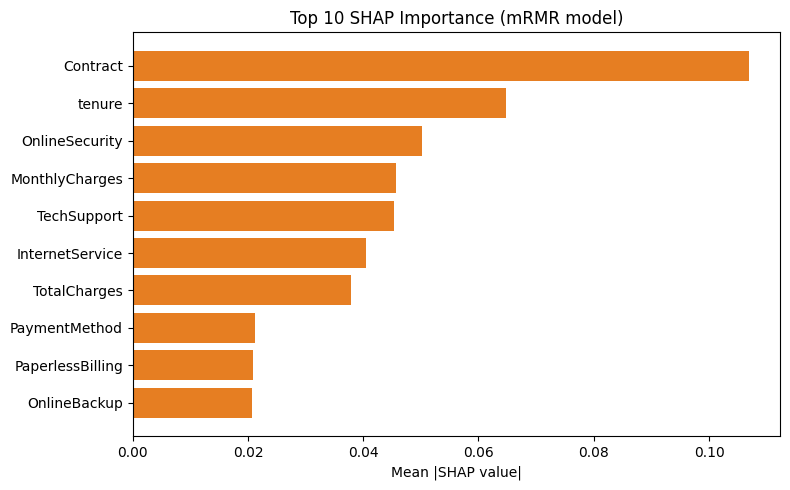

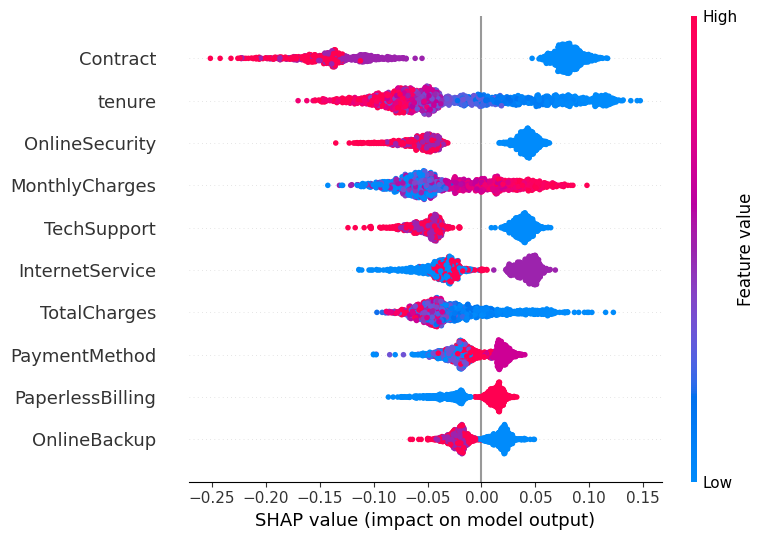

In [12]:
# [Section 5-1] mRMR 모델 SHAP Summary (Top 10)

if "rf_mrmr" not in globals() or "selected_mrmr" not in globals():
    raise ValueError("rf_mrmr 또는 selected_mrmr가 없습니다. Section 2-1(mRMR) 셀을 먼저 실행하세요.")

X_train_mrmr = X_train[selected_mrmr].copy()
X_test_mrmr = X_test[selected_mrmr].copy()

explainer_mrmr = shap.TreeExplainer(rf_mrmr)
shap_values_mrmr = explainer_mrmr.shap_values(X_test_mrmr)

# SHAP 출력 형태 호환 처리 (list 또는 ndarray)
if isinstance(shap_values_mrmr, list):
    # [class0, class1]
    shap_cls1 = shap_values_mrmr[1]
elif isinstance(shap_values_mrmr, np.ndarray) and shap_values_mrmr.ndim == 3:
    # (n_samples, n_features, n_classes)
    shap_cls1 = shap_values_mrmr[:, :, 1]
else:
    # binary일 때 (n_samples, n_features) 형태가 나오는 경우
    shap_cls1 = shap_values_mrmr

# 상위 10개 중요 변수 (mean |SHAP|)
mean_abs_shap = np.abs(shap_cls1).mean(axis=0)
top10_shap_df = (
    pd.DataFrame({"Feature": selected_mrmr, "MeanAbsSHAP": mean_abs_shap})
    .sort_values("MeanAbsSHAP", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("=== mRMR 모델 기준 SHAP 중요도 Top 10 (Churn=1 기준) ===")
display(top10_shap_df)

plt.figure(figsize=(8, 5))
plt.barh(top10_shap_df["Feature"][::-1], top10_shap_df["MeanAbsSHAP"][::-1], color="#e67e22")
plt.title("Top 10 SHAP Importance (mRMR model)")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

# Summary plot (Top 10)
shap.summary_plot(shap_cls1, X_test_mrmr, max_display=10)


**[과제]** 써니는 실제로 이탈(Churn=1)로 예측된 고객 한 명을 골라서 Force Plot으로 어떤 변수들이 이탈 예측에 기여했는지 확인해보고자 합니다. AI를 활용해 관련 코드를 작성해보세요.

5-2 프로폼트
1. 이탈한 고객 index 알려줘
2. 내가 선택한 index 의 force plot 을 그려줘
3. 그린 force plot 으로부터 어떤 변수들이 얼만큼 이탈 예측에 기여했는지 설명해줘

### 5-2 Q&A 정리: 개별 고객 Force Plot 해석

**질문**
1. 이탈(Churn=1)로 예측된 고객 index 확인
2. 선택 index의 Force Plot 시각화
3. Force Plot 기반으로 변수별 기여도(크기/방향) 설명

**수행 방향**
- mRMR 모델 기준 예측 결과에서 `pred=1`인 test index를 먼저 출력
- `selected_index` 변수로 분석할 고객 index를 지정
- SHAP force plot + 상위 기여 변수 표를 함께 출력해 해석 가능하도록 구성

=== Predicted Churn(=1) indices ===
[2280, 5748, 3568, 1639, 3524, 2136, 6529, 761, 6125, 5547, 1838, 6979, 346, 950, 6633, 2519, 5400, 880, 3510, 2246, 2255, 6304, 3408, 3362, 5300, 290, 1472, 642, 6314, 3185] ...
총 489명

분석 대상 index: 2280

=== Force Plot ===


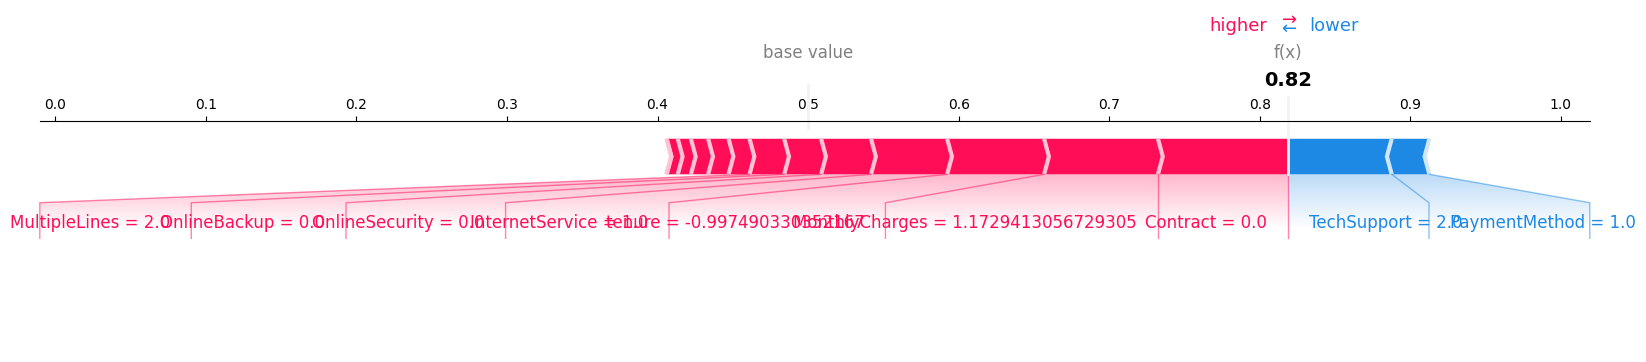


=== Top 10 contribution features (index=2280) ===


,Feature,FeatureValue,SHAP,Direction
0,Contract,0.000000,0.086520,Churn ↑
1,MonthlyCharges,1.172941,0.075631,Churn ↑
2,TechSupport,2.000000,-0.068727,Churn ↓
3,tenure,-0.997490,0.064404,Churn ↑
4,InternetService,1.000000,0.050546,Churn ↑
5,OnlineSecurity,0.000000,0.033158,Churn ↑
6,PaymentMethod,1.000000,-0.025052,Churn ↓
7,OnlineBackup,0.000000,0.024521,Churn ↑
8,MultipleLines,2.000000,0.023030,Churn ↑
9,PaperlessBilling,1.000000,0.013923,Churn ↑


=== 해석 요약 ===
- 양(+)의 기여 합: 0.3717 (이탈 확률을 올리는 방향)
- 음(-)의 기여 합: -0.0938 (이탈 확률을 내리는 방향)
- 표의 SHAP 절대값이 클수록 해당 고객 예측에 더 큰 영향을 준 변수입니다.


In [13]:
# [Section 5-2] 이탈 예측 고객 1명 Force Plot + 기여 변수 설명

if "rf_mrmr" not in globals() or "selected_mrmr" not in globals():
    raise ValueError("rf_mrmr 또는 selected_mrmr가 없습니다. Section 2-1/5-1 셀을 먼저 실행하세요.")

X_test_mrmr = X_test[selected_mrmr].copy()
pred_test_mrmr = rf_mrmr.predict(X_test_mrmr)

# 1) 이탈(1)로 예측된 고객 index 목록
pred_churn_idx = X_test_mrmr.index[pred_test_mrmr == 1].tolist()
print("=== Predicted Churn(=1) indices ===")
print(pred_churn_idx[:30], "..." if len(pred_churn_idx) > 30 else "")
print(f"총 {len(pred_churn_idx)}명")

if len(pred_churn_idx) == 0:
    raise ValueError("이탈(1)로 예측된 고객이 없습니다. 모델/데이터를 확인하세요.")

# 2) 선택 index force plot
# 원하는 고객 index로 바꿔서 실행 가능
selected_index = pred_churn_idx[0]
print(f"\n분석 대상 index: {selected_index}")

explainer_mrmr = shap.TreeExplainer(rf_mrmr)
shap_values_test = explainer_mrmr.shap_values(X_test_mrmr)

# SHAP 형태 호환 처리
if isinstance(shap_values_test, list):
    shap_cls1_all = shap_values_test[1]
elif isinstance(shap_values_test, np.ndarray) and shap_values_test.ndim == 3:
    shap_cls1_all = shap_values_test[:, :, 1]
else:
    shap_cls1_all = shap_values_test

row_pos = X_test_mrmr.index.get_loc(selected_index)
shap_one = shap_cls1_all[row_pos]
x_one = X_test_mrmr.loc[selected_index]

# expected value도 형태 호환
expected_val = explainer_mrmr.expected_value
if isinstance(expected_val, (list, np.ndarray)) and np.array(expected_val).ndim > 0:
    expected_val = np.array(expected_val).reshape(-1)[-1]

print("\n=== Force Plot ===")
shap.force_plot(expected_val, shap_one, x_one, matplotlib=True)

# 3) 기여 변수 설명 (절대 기여도 상위)
contrib_df = pd.DataFrame({
    "Feature": selected_mrmr,
    "FeatureValue": x_one.values,
    "SHAP": shap_one,
})
contrib_df["AbsSHAP"] = contrib_df["SHAP"].abs()
contrib_df = contrib_df.sort_values("AbsSHAP", ascending=False).reset_index(drop=True)

topn = 10
top_contrib = contrib_df.head(topn).copy()
top_contrib["Direction"] = np.where(top_contrib["SHAP"] >= 0, "Churn ↑", "Churn ↓")

print(f"\n=== Top {topn} contribution features (index={selected_index}) ===")
display(top_contrib[["Feature", "FeatureValue", "SHAP", "Direction"]])

pos_sum = top_contrib.loc[top_contrib["SHAP"] > 0, "SHAP"].sum()
neg_sum = top_contrib.loc[top_contrib["SHAP"] < 0, "SHAP"].sum()
print("=== 해석 요약 ===")
print(f"- 양(+)의 기여 합: {pos_sum:.4f} (이탈 확률을 올리는 방향)")
print(f"- 음(-)의 기여 합: {neg_sum:.4f} (이탈 확률을 내리는 방향)")
print("- 표의 SHAP 절대값이 클수록 해당 고객 예측에 더 큰 영향을 준 변수입니다.")

## 6) 분석 결과 종합 및 활용

**[과제]** 써니는 앞선 변수 선택 결과와 SHAP 분석을 종합해서, 이탈 고객을 막으려면 어떤 마케팅을 해야 할지 궁금합니다. AI와 상의하여 이탈로 예측된 고객들이 어떤 변수 때문에 그렇게 예측됐는지 파악하고 그에 맞는 마케팅 방식을 추천받아 보세요.

6-1 프로폼트
1. 어떤변수로 인해 고객들이 예측했는지 나머지 고객들에 대해서도 분석해서 높은 기여도를 갖는 변수 3개 선정해줘.
2. 선정한 3개의 변수에 대해 마켓팅 방안을 각각 추천해줘

### 6-1 Q&A 정리: 이탈예측 고객 전체 요인 + 마케팅 액션

**질문**
1. 이탈로 예측된 고객 전체를 기준으로 기여도 높은 변수 3개 선정
2. 선정 변수별 마케팅 방안 제안

**수행 방향**
- mRMR 모델 예측 결과에서 `pred=1` 고객만 추출
- 해당 집단의 SHAP(Churn=1 기준) 평균 절대값으로 중요도 집계
- Top 3 변수에 대해 실행 가능한 마케팅 액션을 변수별로 매핑

=== Predicted Churn 고객 수 ===
489

=== 기여도 상위 3개 변수 (Predicted Churn 집단 기준) ===


,Feature,MeanAbsSHAP_on_PredChurn
0,Contract,0.083917
1,tenure,0.067484
2,OnlineSecurity,0.048594


=== Top 3 변수별 마케팅 방안 ===


,Feature,MeanAbsSHAP_on_PredChurn,MarketingRecommendation
0,Contract,0.083917,장기약정 전환 인센티브(요금 할인/사은품) + 갱신 시점 사전 리텐션 캠페인
1,tenure,0.067484,가입 초기 고객 온보딩 강화(30/60/90일 케어) + 초반 해지 방지 맞춤 혜택
2,OnlineSecurity,0.048594,"품질/지원 기반 리텐션(장애 선제 안내, TechSupport/보안 부가서비스 번들..."


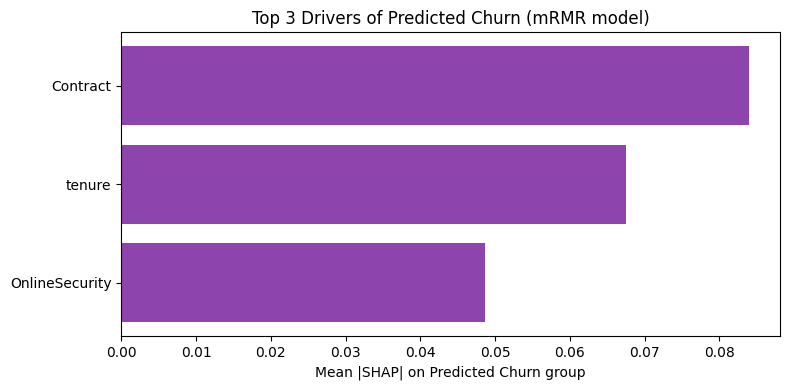

In [14]:
# [Section 6-1] 이탈예측 고객 전체 분석 + Top3 변수 마케팅 방안

if "rf_mrmr" not in globals() or "selected_mrmr" not in globals():
    raise ValueError("rf_mrmr 또는 selected_mrmr가 없습니다. Section 2-1/5-1 셀을 먼저 실행하세요.")

X_test_mrmr = X_test[selected_mrmr].copy()
pred_test_mrmr = rf_mrmr.predict(X_test_mrmr)

# 이탈(1)로 예측된 고객 전체
pred_churn_mask = pred_test_mrmr == 1
X_churn_pred = X_test_mrmr.loc[pred_churn_mask]

if X_churn_pred.shape[0] == 0:
    raise ValueError("이탈(1) 예측 고객이 없습니다. 모델 또는 데이터 상태를 확인하세요.")

explainer_mrmr = shap.TreeExplainer(rf_mrmr)
shap_values_test = explainer_mrmr.shap_values(X_test_mrmr)

# SHAP 형태 호환 처리
if isinstance(shap_values_test, list):
    shap_cls1_all = shap_values_test[1]
elif isinstance(shap_values_test, np.ndarray) and shap_values_test.ndim == 3:
    shap_cls1_all = shap_values_test[:, :, 1]
else:
    shap_cls1_all = shap_values_test

# pred=1 집단의 SHAP만 집계
shap_churn_pred = shap_cls1_all[pred_churn_mask]
mean_abs_shap_churn = np.abs(shap_churn_pred).mean(axis=0)

top3_df = (
    pd.DataFrame({
        "Feature": selected_mrmr,
        "MeanAbsSHAP_on_PredChurn": mean_abs_shap_churn,
    })
    .sort_values("MeanAbsSHAP_on_PredChurn", ascending=False)
    .head(3)
    .reset_index(drop=True)
)

print("=== Predicted Churn 고객 수 ===")
print(X_churn_pred.shape[0])

print("\n=== 기여도 상위 3개 변수 (Predicted Churn 집단 기준) ===")
display(top3_df)

# 변수명 기반 마케팅 액션 추천 규칙
def recommend_action(feature_name):
    f = feature_name.lower()
    if "contract" in f:
        return "장기약정 전환 인센티브(요금 할인/사은품) + 갱신 시점 사전 리텐션 캠페인"
    if "tenure" in f:
        return "가입 초기 고객 온보딩 강화(30/60/90일 케어) + 초반 해지 방지 맞춤 혜택"
    if "monthlycharges" in f or "totalcharges" in f or "charges" in f:
        return "요금 부담 완화 프로모션(요금제 다운셀/결합할인/한시적 크레딧)"
    if "internetservice" in f or "techsupport" in f or "onlinesecurity" in f:
        return "품질/지원 기반 리텐션(장애 선제 안내, TechSupport/보안 부가서비스 번들 제공)"
    if "paymentmethod" in f or "paperlessbilling" in f:
        return "결제 편의 개선(자동이체/간편결제 전환 유도) + 청구 커뮤니케이션 최적화"
    return "해당 변수 고위험 고객군 세그먼트 타겟 캠페인(혜택 A/B 테스트)"

marketing_df = top3_df.copy()
marketing_df["MarketingRecommendation"] = marketing_df["Feature"].apply(recommend_action)

print("=== Top 3 변수별 마케팅 방안 ===")
display(marketing_df)

# 시각화
plt.figure(figsize=(8, 4))
plt.barh(marketing_df["Feature"][::-1], marketing_df["MeanAbsSHAP_on_PredChurn"][::-1], color="#8e44ad")
plt.title("Top 3 Drivers of Predicted Churn (mRMR model)")
plt.xlabel("Mean |SHAP| on Predicted Churn group")
plt.tight_layout()
plt.show()

# 이후 보고용 변수
# - top3_df, marketing_df

### 전략가 메모: Churn 저감 통합 전략 (Contract · Tenure · OnlineSecurity)

#### 1) 우선순위 설정 (Why first?)
1. **Contract (최우선)**
   - 해지 의사결정에 가장 직접적인 레버리지(약정 구조/요금 조건/갱신 정책).
   - 실행 시점이 명확하고(갱신 전/만료 전), 캠페인 효과 측정이 쉬움.
2. **Tenure (두 번째)**
   - 이탈 위험이 고객 생애주기별로 다르게 나타남(초기·중기·장기).
   - 같은 혜택도 tenure 구간별로 반응이 달라 세그먼트 전략이 필요.
3. **OnlineSecurity (세 번째, 증폭 변수)**
   - 단독 가격혜택보다 "서비스 가치 인식"을 높여 장기 유지율을 끌어올리는 역할.
   - Contract/tenure 전략과 결합 시 효과가 커짐(번들/체험/유지 패키지).

#### 2) 방향성 (How to think)
- **가격 방어만 하지 말고, 계약 구조 + 라이프사이클 + 보안가치**를 묶어서 설계.
- 단기 할인 중심 대응을 줄이고, **재약정 전환율/초기 90일 유지율/보안 부가서비스 채택률**을 핵심 KPI로 관리.
- 개인별 1:1 최적화보다 먼저, **세그먼트 기반 표준 플레이북**을 만들어 반복 실행.

#### 3) 실행 방법 추천 (What to do)
- **A. Contract 전략 (Priority 1)**
  - 만료 60/30/7일 전 리텐션 시퀀스(알림+오퍼+상담 연결) 자동화.
  - Month-to-month 고객 대상: 12개월 전환 오퍼(요금할인/설치비 면제/결합혜택).
  - 고위험군에는 "단기 할인"보다 "약정 전환 + 서비스 업그레이드" 패키지 제안.

- **B. Tenure 전략 (Priority 2)**
  - `0~3개월`: 온보딩 집중(개통 후 7일/30일/60일 헬스체크, 불만 사전 제거).
  - `4~12개월`: 사용패턴 기반 요금제 최적화 제안(과금 불만 최소화).
  - `12개월+`: 로열티 혜택(장기 고객 전용 보상, 업셀/크로스셀).

- **C. OnlineSecurity 전략 (Priority 3)**
  - 고위험 세그먼트에 보안 부가서비스 무료 체험(1~3개월) + 자동 전환 옵션.
  - 보안 미가입 고객에게 위험 시나리오 기반 메시지(계정탈취/피싱 예방)로 가치 커뮤니케이션.
  - TechSupport/Internet 품질 개선 캠페인과 묶어 "안정성 패키지"로 판매.

#### 4) 근거 (Evidence)
- SHAP 상위 변수는 실제 예측에서 기여도가 큰 변수이므로, **리텐션 개입 우선순위**를 정하는 데 타당함.
- Contract는 고객의 비용·락인 구조를 바꾸는 직접 레버리지라 단기 churn 방어 효과가 큼.
- Tenure는 churn 위험의 시간축 패턴을 설명하므로 동일 캠페인 일괄 적용보다 구간별 전략이 효율적.
- OnlineSecurity는 체감가치/신뢰를 높여 가격 민감도를 낮추는 보완축으로 작동함.

#### 5) 운영 KPI 제안
- Contract: 재약정 전환율, 만료 전 해지율
- Tenure: 초기 90일 유지율, 구간별 churn율
- OnlineSecurity: 보안 부가서비스 채택률, 채택군 churn uplift
- 최종: 전체 F1 개선 + 실제 월간 churn 감소율

=== 재전처리 결과 ===
train shape: (5634, 40), test shape: (1409, 40)
numeric=4, binary_label=5, multi_onehot=10


100%|██████████| 39/39 [00:06<00:00,  6.44it/s]



=== mRMR k별 CV 결과 ===


,k,CV_F1_mean,CV_F1_std
0,25,0.637134,0.018631
1,30,0.634992,0.023962
2,35,0.633355,0.024603
3,20,0.632174,0.017728
4,40,0.631623,0.023342
5,15,0.631611,0.016242
6,10,0.631253,0.014881
7,5,0.606128,0.012026


best_k: 25

=== 재검증 성능 비교 (F1 기준) ===


,Method,n_features,Accuracy,Precision,Recall,F1-score
0,All Features,40,0.769340,0.549098,0.732620,0.627721
1,mRMR (k=25),25,0.765791,0.543651,0.732620,0.624146
2,Boruta (4),4,0.759404,0.534791,0.719251,0.613455


최종 선택 모델: All Features

=== SHAP Top 10 ===


,Feature,MeanAbsSHAP
0,Contract_Month-to-month,0.081541
1,tenure,0.050337
2,InternetService_Fiber optic,0.044779
3,Contract_Two year,0.034953
4,TotalCharges,0.034762
5,OnlineSecurity_No,0.033230
6,TechSupport_No,0.032849
7,PaymentMethod_Electronic check,0.023542
8,MonthlyCharges,0.022636
9,InternetService_DSL,0.017937



=== Force Plot index: 2280 ===


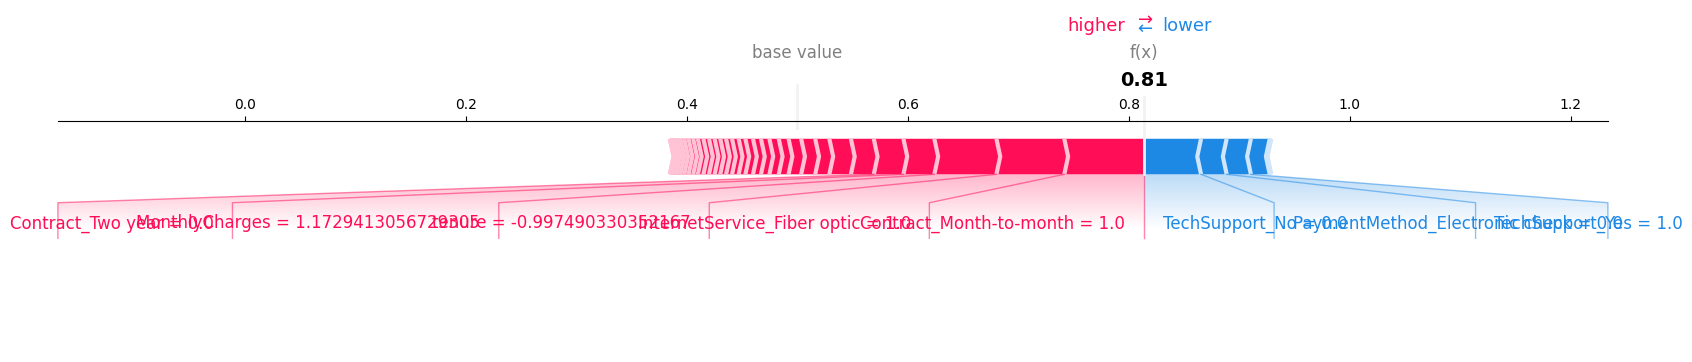


=== Predicted Churn Top 3 drivers + Marketing ===


,Feature,MeanAbsSHAP_on_PredChurn,MarketingRecommendation
0,Contract_Month-to-month,0.065734,약정 전환 인센티브(요금 할인/결합혜택) + 만료 전 리텐션 시퀀스
1,tenure,0.053016,가입 구간별(초기/중기/장기) 차등 케어와 온보딩 강화
2,InternetService_Fiber optic,0.047844,고위험 세그먼트 대상 개인화 리텐션 캠페인 A/B 테스트



=== Priority axes (contract/tenure/onlinesecurity) ===


,Axis,MeanAbsSHAP,n_cols
0,tenure,0.050337,1
1,contract,0.043204,3
2,onlinesecurity,0.016239,3



[완료] 조건 변경 재검증 파이프라인 실행 완료


In [16]:
# [재검증] 전처리 조건 변경 + 동일 분석 파이프라인 전체 실행
# 조건
# 1) 이진 범주형만 Label Encoding, 다중 범주형은 One-Hot Encoding
# 2) mRMR k 후보: 5,10,15,...,40
# 3) k별 F1 비교 후 최적 k 선택

import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

from mrmr import mrmr_classif
from boruta import BorutaPy


def evaluate_classification(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
    }


def winsorize_iqr(df_in, cols):
    df_out = df_in.copy()
    for col in cols:
        q1, q3 = df_out[col].quantile(0.25), df_out[col].quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        df_out[col] = df_out[col].clip(lo, hi)
    return df_out


def shap_class1_values(explainer, shap_values):
    if isinstance(shap_values, list):
        return shap_values[1]
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        return shap_values[:, :, 1]
    return shap_values


def recommend_action(feature_name):
    f = feature_name.lower()
    if "contract" in f:
        return "약정 전환 인센티브(요금 할인/결합혜택) + 만료 전 리텐션 시퀀스"
    if "tenure" in f:
        return "가입 구간별(초기/중기/장기) 차등 케어와 온보딩 강화"
    if "onlinesecurity" in f:
        return "보안 부가서비스 체험 제공 + TechSupport 번들 패키지"
    if "monthlycharges" in f or "totalcharges" in f or "charges" in f:
        return "요금 부담 완화(요금제 최적화/한시 크레딧)"
    return "고위험 세그먼트 대상 개인화 리텐션 캠페인 A/B 테스트"


# ------------------------------------------------------------------
# 0) 데이터 로드 + 기본 전처리
# ------------------------------------------------------------------
df_re = pd.read_csv(os.path.join("dataset", "day5_miniproject.csv"))
df_re["Churn"] = df_re["Churn"].map({"Yes": 1, "No": 0})

# 결측 처리: 범주형 mode, 수치형 KNN
cat_cols_all = df_re.select_dtypes(include=["object"]).columns.tolist()
num_cols_all = [c for c in df_re.select_dtypes(include=["number"]).columns if c != "Churn"]

cat_imputer = SimpleImputer(strategy="most_frequent")
df_re[cat_cols_all] = cat_imputer.fit_transform(df_re[cat_cols_all])

scaler_imp = StandardScaler()
X_num_scaled = scaler_imp.fit_transform(df_re[num_cols_all])
knn_imp = KNNImputer(n_neighbors=5)
X_num_imputed = knn_imp.fit_transform(X_num_scaled)
df_re[num_cols_all] = scaler_imp.inverse_transform(X_num_imputed)

# 이상치 처리(윈저화)
df_re = winsorize_iqr(df_re, num_cols_all)

# 분할 (8:2 유지)
X_raw = df_re.drop(columns=["Churn"])
Y = df_re["Churn"]

X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(
    X_raw, Y, test_size=0.2, random_state=42, stratify=Y
)

# ------------------------------------------------------------------
# 1) 인코딩 규칙 변경: binary -> Label, multi -> OneHot
# ------------------------------------------------------------------
num_cols = X_train_raw.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train_raw.select_dtypes(include=["object"]).columns.tolist()

binary_cols = [c for c in cat_cols if X_train_raw[c].nunique() == 2]
multi_cols = [c for c in cat_cols if X_train_raw[c].nunique() > 2]

X_train_num = X_train_raw[num_cols].copy()
X_test_num = X_test_raw[num_cols].copy()

scaler = StandardScaler()
X_train_num[num_cols] = scaler.fit_transform(X_train_num[num_cols])
X_test_num[num_cols] = scaler.transform(X_test_num[num_cols])

# binary label encoding
X_train_bin = pd.DataFrame(index=X_train_raw.index)
X_test_bin = pd.DataFrame(index=X_test_raw.index)
label_encoders_re = {}

for col in binary_cols:
    le = LabelEncoder()
    X_train_bin[col] = le.fit_transform(X_train_raw[col].astype(str))
    mapping = {cls: idx for idx, cls in enumerate(le.classes_)}
    X_test_bin[col] = X_test_raw[col].astype(str).map(mapping)
    X_test_bin[col] = X_test_bin[col].fillna(X_train_bin[col].mode()[0]).astype(int)
    label_encoders_re[col] = le

# multi one-hot encoding
if len(multi_cols) > 0:
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

    X_train_ohe_arr = ohe.fit_transform(X_train_raw[multi_cols].astype(str))
    X_test_ohe_arr = ohe.transform(X_test_raw[multi_cols].astype(str))
    ohe_cols = ohe.get_feature_names_out(multi_cols)

    X_train_ohe = pd.DataFrame(X_train_ohe_arr, index=X_train_raw.index, columns=ohe_cols)
    X_test_ohe = pd.DataFrame(X_test_ohe_arr, index=X_test_raw.index, columns=ohe_cols)
else:
    X_train_ohe = pd.DataFrame(index=X_train_raw.index)
    X_test_ohe = pd.DataFrame(index=X_test_raw.index)

X_train = pd.concat([X_train_num, X_train_bin, X_train_ohe], axis=1)
X_test = pd.concat([X_test_num, X_test_bin, X_test_ohe], axis=1)

print("=== 재전처리 결과 ===")
print(f"train shape: {X_train.shape}, test shape: {X_test.shape}")
print(f"numeric={len(num_cols)}, binary_label={len(binary_cols)}, multi_onehot={len(multi_cols)}")

# ------------------------------------------------------------------
# 2) Baseline RF (all features)
# ------------------------------------------------------------------
rf_params = {
    "n_estimators": 400,
    "max_depth": 10,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
}

rf_all_re = RandomForestClassifier(**rf_params)
rf_all_re.fit(X_train, Y_train)
pred_all_re = rf_all_re.predict(X_test)
metrics_all_re = evaluate_classification(Y_test, pred_all_re)

# ------------------------------------------------------------------
# 3) mRMR (k=5..40 step5) + CV F1로 best k 선택
# ------------------------------------------------------------------
k_candidates = [k for k in range(5, 41, 5) if k <= X_train.shape[1]]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mrmr_cv_rows = []
for k in k_candidates:
    selected_k = mrmr_classif(X=X_train, y=Y_train, K=k)

    fold_f1 = []
    for tr_idx, va_idx in skf.split(X_train, Y_train):
        X_tr = X_train.iloc[tr_idx][selected_k]
        X_va = X_train.iloc[va_idx][selected_k]
        y_tr = Y_train.iloc[tr_idx]
        y_va = Y_train.iloc[va_idx]

        m = RandomForestClassifier(**rf_params)
        m.fit(X_tr, y_tr)
        p = m.predict(X_va)
        fold_f1.append(f1_score(y_va, p, zero_division=0))

    mrmr_cv_rows.append({
        "k": k,
        "CV_F1_mean": np.mean(fold_f1),
        "CV_F1_std": np.std(fold_f1),
        "selected_features": selected_k,
    })

mrmr_cv_df = pd.DataFrame(mrmr_cv_rows).sort_values("CV_F1_mean", ascending=False).reset_index(drop=True)
best_k_re = int(mrmr_cv_df.loc[0, "k"])
selected_mrmr_re = mrmr_cv_df.loc[0, "selected_features"]

rf_mrmr_re = RandomForestClassifier(**rf_params)
rf_mrmr_re.fit(X_train[selected_mrmr_re], Y_train)
pred_mrmr_re = rf_mrmr_re.predict(X_test[selected_mrmr_re])
metrics_mrmr_re = evaluate_classification(Y_test, pred_mrmr_re)

print("\n=== mRMR k별 CV 결과 ===")
display(mrmr_cv_df[["k", "CV_F1_mean", "CV_F1_std"]])
print(f"best_k: {best_k_re}")

# ------------------------------------------------------------------
# 4) Boruta (optimized)
# ------------------------------------------------------------------
rf_boruta_base_re = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

boruta_re = BorutaPy(
    estimator=rf_boruta_base_re,
    n_estimators="auto",
    max_iter=50,
    perc=95,
    random_state=42,
)
boruta_re.fit(X_train.values, Y_train.values)

selected_boruta_re = X_train.columns[boruta_re.support_].tolist()
if len(selected_boruta_re) == 0:
    # 안전장치: confirmed가 0이면 weak 포함 상위 일부 사용
    weak_cols = X_train.columns[boruta_re.support_weak_].tolist()
    selected_boruta_re = weak_cols[:min(10, len(weak_cols))]

rf_boruta_re = RandomForestClassifier(**rf_params)
rf_boruta_re.fit(X_train[selected_boruta_re], Y_train)
pred_boruta_re = rf_boruta_re.predict(X_test[selected_boruta_re])
metrics_boruta_re = evaluate_classification(Y_test, pred_boruta_re)

# ------------------------------------------------------------------
# 5) 성능 비교
# ------------------------------------------------------------------
compare_re = pd.DataFrame([
    {"Method": "All Features", "n_features": X_train.shape[1], **metrics_all_re},
    {"Method": f"mRMR (k={best_k_re})", "n_features": len(selected_mrmr_re), **metrics_mrmr_re},
    {"Method": f"Boruta ({len(selected_boruta_re)})", "n_features": len(selected_boruta_re), **metrics_boruta_re},
]).sort_values("F1-score", ascending=False).reset_index(drop=True)

print("\n=== 재검증 성능 비교 (F1 기준) ===")
display(compare_re)

best_method_re = compare_re.loc[0, "Method"]
print(f"최종 선택 모델: {best_method_re}")

# best model 매핑
model_map_re = {
    "All Features": (rf_all_re, X_train.columns.tolist()),
    f"mRMR (k={best_k_re})": (rf_mrmr_re, selected_mrmr_re),
    f"Boruta ({len(selected_boruta_re)})": (rf_boruta_re, selected_boruta_re),
}
best_model_re, best_features_re = model_map_re[best_method_re]

# ------------------------------------------------------------------
# 6) SHAP Top10 + Force Plot + 종합 마케팅
# ------------------------------------------------------------------
X_test_best = X_test[best_features_re].copy()
X_train_best = X_train[best_features_re].copy()

explainer_re = shap.TreeExplainer(best_model_re)
shap_values_re = explainer_re.shap_values(X_test_best)
shap_cls1_re = shap_class1_values(explainer_re, shap_values_re)

# Top 10
mean_abs_shap_re = np.abs(shap_cls1_re).mean(axis=0)
top10_re = (
    pd.DataFrame({"Feature": best_features_re, "MeanAbsSHAP": mean_abs_shap_re})
    .sort_values("MeanAbsSHAP", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print("\n=== SHAP Top 10 ===")
display(top10_re)

# Force plot 대상: pred=1 첫 고객
pred_best = best_model_re.predict(X_test_best)
pred_idx = X_test_best.index[pred_best == 1].tolist()
if len(pred_idx) > 0:
    selected_index_re = pred_idx[0]
    row_pos = X_test_best.index.get_loc(selected_index_re)
    shap_one_re = shap_cls1_re[row_pos]
    x_one_re = X_test_best.loc[selected_index_re]

    expected_re = explainer_re.expected_value
    if isinstance(expected_re, (list, np.ndarray)) and np.array(expected_re).ndim > 0:
        expected_re = np.array(expected_re).reshape(-1)[-1]

    print(f"\n=== Force Plot index: {selected_index_re} ===")
    shap.force_plot(expected_re, shap_one_re, x_one_re, matplotlib=True)

# Pred churn 집단 Top3 + 마케팅
pred_churn_mask_re = pred_best == 1
if pred_churn_mask_re.sum() > 0:
    shap_pred_re = shap_cls1_re[pred_churn_mask_re]
    top3_re = (
        pd.DataFrame({
            "Feature": best_features_re,
            "MeanAbsSHAP_on_PredChurn": np.abs(shap_pred_re).mean(axis=0),
        })
        .sort_values("MeanAbsSHAP_on_PredChurn", ascending=False)
        .head(3)
        .reset_index(drop=True)
    )
    top3_re["MarketingRecommendation"] = top3_re["Feature"].apply(recommend_action)

    print("\n=== Predicted Churn Top 3 drivers + Marketing ===")
    display(top3_re)

# contract/tenure/onlinesecurity 3축 우선순위 점수 (고정 축 검증)
priority_axes = ["contract", "tenure", "onlinesecurity"]
priority_rows = []
for key in priority_axes:
    cols = [c for c in best_features_re if key in c.lower()]
    if len(cols) == 0:
        score = 0.0
    else:
        idxs = [best_features_re.index(c) for c in cols]
        score = float(np.abs(shap_cls1_re[:, idxs]).mean())
    priority_rows.append({"Axis": key, "MeanAbsSHAP": score, "n_cols": len(cols)})

priority_df = pd.DataFrame(priority_rows).sort_values("MeanAbsSHAP", ascending=False).reset_index(drop=True)
print("\n=== Priority axes (contract/tenure/onlinesecurity) ===")
display(priority_df)

print("\n[완료] 조건 변경 재검증 파이프라인 실행 완료")